1. Import Libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
# %matplotlib inline

In [16]:
df = sns.load_dataset('tips')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


# Histogram of Total Bill

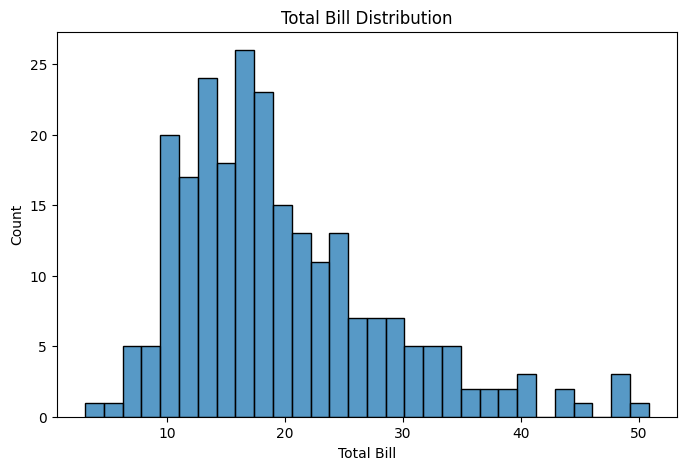

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_bill'], bins=30)
plt.title('Total Bill Distribution')
plt.xlabel('Total Bill')
plt.ylabel('Count')
plt.show()

Shows how many customers paid certain bill amounts; most paid lower bills.

# Box Plot: Total Bill by Day and Sex

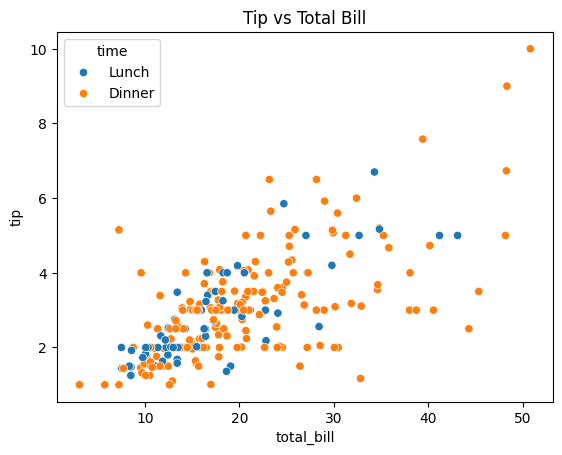

In [18]:
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time')
plt.title('Tip vs Total Bill')
plt.show()

Shows median, spread, and outliers for each day by gender.

# Violin Plot: Tip by Smoker

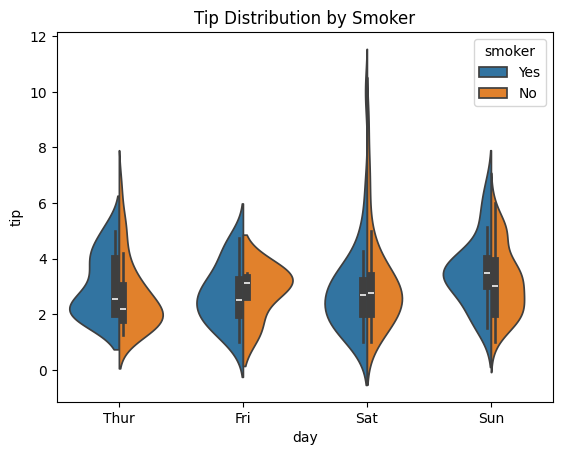

In [19]:
sns.violinplot(data=df, x='day', y='tip', hue='smoker', split=True)
plt.title('Tip Distribution by Smoker')
plt.show()

Shows density of tip values for smokers vs non-smokers.
" Graph dikhata hai ke smokers aur non-smokers ka tip distribution day-wise different hai. Smokers Saturday aur Sunday me thoda zyada aur varied tips dete hain, non-smokers ka spread chhota aur median low hai.”  "

# Interactive Scatter

In [13]:
pip install nbformat --upgrade

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
fig = px.scatter(df, x='total_bill', y='tip', color='time', size='size', hover_data=['sex'], title='Interactive Scatter: Tip vs Total Bill')
fig.show(renderer="browser")

In [21]:
fig = px.scatter(df, x='total_bill', y='tip', color='time', size='size', hover_data=['sex'], title='Interactive Scatter: Tip vs Total Bill')
fig.show()

Interactive scatter; size shows party size, color shows meal time.

# Bar Plot: Average Tip by Day

In [5]:
avg_tip = df.groupby('day')['tip'].mean().reset_index()
fig = px.bar(avg_tip, x='day', y='tip', color='tip', title='Average Tip by Day')
fig.show()

C:\Users\PMLS\AppData\Local\Temp\ipykernel_19132\3176588338.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_tip = df.groupby('day')['tip'].mean().reset_index()


Highlights which day customers tipped more on average.

# Pie Chart: Lunch vs Dinner

In [22]:
fig = px.pie(df, names='time', title='Lunch vs Dinner Count')
fig.show()

Percentage of lunch vs dinner customers.

# Sunburst Chart: Total Bill by Day and Gender

In [27]:
fig = px.sunburst(df, path=['day','sex'], values='total_bill', title='Total Bill by Day and Gender',color='total_bill')
fig.show()

Hierarchical view showing total bills across days and gender.

#  Box Plot with Plotly

In [28]:
fig = px.box(df, x='day', y='total_bill', color='sex', points='all', title='Total Bill Box Plot by Day and Gender', color_discrete_map={'Male': 'blue', 'Female': 'red'})
fig.show()

Visualizes median, spread, and outliers for total bill per day and gender.

# Violin Plot with Plotly

In [29]:
fig = px.violin(df, x='day', y='tip', color='smoker', box=True, points='all', title='Tip Distribution by Smoker', color_discrete_map={'Yes': 'orange', 'No': 'green'})
fig.show()

Density and spread of tips by smoker status.

# Bubble Plot: Tip vs Total Bill

In [10]:
fig = px.scatter(df, x='total_bill', y='tip', size='size', color='day', hover_data=['sex','time'], title='Bubble Plot: Tip vs Total Bill')
fig.show()

Bubble size represents party size; color represents day.

# Facet Plot: Tip vs Total Bill

In [37]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [11]:
fig = px.scatter(df, x='total_bill', y='tip', color='sex', facet_col='smoker', title='Tip vs Total Bill by Smoker')
fig.show()

Compare scatter plots for smokers vs non-smokers.

# Animated Scatter: Tip vs Total Bill by Day

In [32]:
fig = px.scatter(df, x='total_bill', y='tip', animation_frame='day', animation_group='size', size='size', color='sex', hover_name='time', title='Animated Tips vs Total Bill by Day', color_discrete_map={'Male': 'blue', 'Female': 'yellow'})
fig.show()

Animation shows how tip vs bill changes across days.

# Animated Bubble: Party Size Effect

In [36]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [33]:
fig = px.scatter(df, x='total_bill', y='tip', size='size', color='day', animation_frame='size', title='Animated Bubble by Party Size')
fig.show()

Demonstrates effect of party size on tip dynamically.

# Sunburst Alternative: Tip by Day and Smoker

In [14]:
fig = px.sunburst(df, path=['day','smoker'], values='tip', title='Tip Distribution by Day and Smoker')
fig.show()

Hierarchical pie showing tips by day and smoker status.